
## MScFE 600 FINANCIAL DATA

---

# **GRADED CODE ACTIVITY M1**

|  |  |
|:---|:---|
|**Total Questions** | 8 questions  |
|**Point Total** |  80 points  |
|**Lessons Covered** |  Lesson 2, Lesson 3, Leson 4 |
|**Key Concepts** | Data Manipulation, Yield Curve Analysis, Nelson Siegel Model, PCA |


---





## Introduction

In this code activity, you will work with real historical US yield data to practice processing data, analysing data and building models.

This assignment is divided into 5 parts:

#### Part 1: Load the Data
Load the CSV file containing historical Treasury yields into a pandas DataFrame.

#### Part 2: Data Investigation and Quality Checks
Perform basic data exploration and quality checks to understand the dataset.

#### Part 3: Yield Curve Analysis
Use the data to analyze the yield curve shape for a specific date.

#### Part 4: Fit Nelson Siegel Model
Fit a Nelson Siegel Model with the data.

#### Part 5: Principal Component Analysis
Conduct Principal Component Analysis on the data.


## Instructions

1. Read through this Jupyter notebook and execute code cells sequentially.
2. For a cell with the title beginning with "Code Task:", you will need to complete the code in the cell following the instructions provided above the cell and in the cell.
3. Only write code below "TODO: Complete your code here". Do not change the code above it.
4. There are hints and partial code in Code Task cells to help you complete the code. Read the hints and complete the code with the partial code.
5. Once you complete a Code Task cell, execute it (press ▶ icon). After executing this cell, go to the left panel called 'Check Activities'. On the left panel, look for the activity code that matches the Code Task code (FD-GCA-M1-xx). Once located the corresponding activity code, click 'Check activity' icon. If your code is correct, there will be a 'Correct' icon shows on the right side of 'Check activity' icon. Then you can move on and continue the Juypter notebook.
6. If you get 'Wrong Answer. Try Again' message after clicking 'Check activity' icon, go back to the Code Task cell and revise the code according to the message provided under 'Check activity'. Then try again until you get the 'Correct' icon.
7. There are also multiple choice questions. Please read the question and select the best option among all available options. Then click 'Check activity'. If the selected option is the correct answer, the "Correct" icon will show on the right side of the 'Check activity'.

## Part 1: Load Yield Data
In this part, we are going to load the Treasury yeild dataset for upcoming analysis.

In [1]:
# Load the dataset for analysis

import pandas as pd
import numpy as np

# Define the yeild CSV filename
TEST_CSV_FILE = 'US_Yields.csv'

# Load the csv dataset
df = pd.read_csv(TEST_CSV_FILE, index_col = 0)
df.index = pd.to_datetime(df.index)

df.head()

,1_Month,3_Month,6_Month,1_Year,2_Year,3_Year,5_Year,7_Year,10_Year,20_Year,30_Year
Date,,,,,,,,,,,
2001-07-31,3.67,3.54,3.47,3.53,3.79,4.06,4.57,4.86,5.07,5.61,5.51
2001-08-01,3.65,3.53,3.47,3.56,3.83,4.09,4.62,4.90,5.11,5.63,5.53
2001-08-02,3.65,3.53,3.46,3.57,3.89,4.17,4.69,4.97,5.17,5.68,5.57
2001-08-03,3.63,3.52,3.47,3.57,3.91,4.22,4.72,4.99,5.20,5.70,5.59
2001-08-06,3.62,3.52,3.47,3.56,3.88,4.17,4.71,4.99,5.19,5.70,5.59


From the above dataset preview, we can see the Date is the index column. The dataset also contains yields from 1 month to 30 year treasuries.

## Part 2: Data Investigation
Next, we are implementing a function to inspect the data and get some basic information about the data.

**Function Requirements:**
- **Function Name**: `investigate_data`
- **Input**:
  - `df`: pandas DataFrame - The loaded yield data
- **Output**:
  - A dictionary containing:
    - `'num_rows'`: int - Number of rows in the dataset
    - `'num_columns'`: int - Number of columns in the dataset
    - `'date_range'`: tuple - (earliest_date, latest_date) as strings in 'YYYY-MM-DD' format
    - `'column_names'`: list - List of all column names

**Example Output:**
```python
{
    'num_rows': 1234,
    'num_columns': 5,
    'date_range': ('1975-01-02', '2021-12-31'),
    'column_names': ['1 Month', '3 Month', '6 Month', '1 Year', '2 Year', '3 Year','5 Year', '7 Year', '10 Year', '20 Year', '30 Year']
}
```


### Code Task: FD-GCA-M1-Q1

In [9]:
##############################################
# FD-GCA-M1-Q1
###############################################
# Create a function to investigate the dataset

def investigate_data(df):
    ####################################
    # TODO: Complete your code here
    ####################################
    # Hint: Use df.shape to find row number and column number of the dataset
    num_rows = df.shape[0]
    num_columns = df.shape[1]
    # Hint: Use df.index, min() and strftime to find the earliest date of the datas
    earliest_date = df.index.min().strftime('%Y-%m-%d')
    # Hint: Use df.index, max() and strftime to find the latest date of the dataset
    latest_date = df.index.max().strftime('%Y-%m-%d')
    # Hint: Use tolist() to find column names of the dataset
    column_names = df.columns.tolist()
    
    result = {
        'num_rows': num_rows,
        'num_columns': num_columns,
        'date_range': (earliest_date, latest_date),
        'column_names': column_names
    }

    return result

Now, let's check the data with this function.

In [11]:
investigate_data(df)

{'num_rows': 5693,
 'num_columns': 11,
 'date_range': ('2001-07-31', '2024-05-03'),
 'column_names': ['1_Month',
  '3_Month',
  '6_Month',
  '1_Year',
  '2_Year',
  '3_Year',
  '5_Year',
  '7_Year',
  '10_Year',
  '20_Year',
  '30_Year']}

### Multiple Choice: FD-GCA-M1-Q2
Based on the above dataset, please answer this quetion on the left panel.

In [13]:
# Feel free to use this cell to find out answer for FD-GCA-M1-Q2
six_month = df['6_Month']
six_month.std()

np.float64(1.7468294699455325)

## Part 3: Yield Curve Analysis with Real Data

In this section, you'll implement a function that extracts the 2-year and 10-year yields for a specific date and computes the slope and shape of the yield curve.

**Function Requirements:**
- **Function Name**: `analyze_yield_curve_from_data`
- **Input**:
  - `df`: pandas DataFrame - The loaded yield data with datetime index
  - `date`: string - Date in 'YYYY-MM-DD' format (e.g., '2020-01-03')
- **Output**:
  - A tuple containing three elements:
    1. `yield_2y`: float - The 2-year yield value for the specified date
    2. `yield_10y`: float - The 10-year yield value for the specified date
    3. `analysis`: tuple - (slope, shape) where:
       - `slope`: float - The yield curve slope (10-year yield - 2-year yield)
       - `shape`: string - The classification as "normal", "flat", or "inverted"

**Classification Rules:**
- Return `"normal"` if 10Y yield > 2Y yield by more than 0.1 percentage points
- Return `"flat"` if the absolute difference between yields is ≤ 0.1 percentage points
- Return `"inverted"` if 2Y yield > 10Y yield (negative slope)

**Example Output:**

For date '2020-01-03' with 2 Year = 1.53% and 10 Year = 1.80%

Output: (1.53, 1.80, (0.27, "normal"))


### Code Task: FD-GCA-M1-Q3

In [19]:
##############################################
# FD-GCA-M1-Q3
###############################################
# Create a function to investigate the dataset

def analyze_yield_curve_from_data(df, date):
   
    ####################################
    # TODO: Complete your code here
    ####################################

    # Hint: Convert date string to datetime: pd.to_datetime(date)
    date_dt = pd.to_datetime(date)
    
    # Check if date exists in the DataFrame
    if date_dt not in df.index:
        raise ValueError(f"Date {date} not found in the dataset.")
        
    # Hint: Extract 2-year and 10-year yields using df.loc()
    yield_2y = df.loc[date,'2_Year']
    yield_10y = df.loc[date,'10_Year']
    
    # Hint: Calculate slope = yield_10y - yield_2y
    slope = yield_10y - yield_2y
    
    # Hint: Classify shape based on slope (slope >0.1: "normal", abs(slope) <=0.1: "flat", else: "inverted"
    if slope >0.1:
        shape = "normal"
    elif abs(slope) <=0.1:
        shape = "flat"
    else:
        shape = "inverted"
    
    # Return the complete analysis
    return (float(yield_2y), float(yield_10y), (float(slope), shape))

### Multiple Choice: FD-GCA-M1-Q4
Apply the above function with the dataset to answer this quetion on the left panel. 

In [25]:
# Feel free to use this cell to find out answer for FD-GCA-M1-Q4
analyze_yield_curve_from_data(df, '2007-04-03')

(4.63, 4.67, (0.040000000000000036, 'flat'))

## Part 4: Fit Nelson-Siegel Model to Treasury Yield Curve

Your task is to implement the Nelson-Siegel yield function that will be used to fit a yield curve model to actual Treasury data.

**Function Requirements:**
- **Function Name**: `nelson_siegel`
- **Input**:
  - `maturity`: numpy array - Time to maturity in years
  - 'beta_0': float - Level parameter
  - 'beta_1': float - Slope parameter
  - 'beta_2': float - Curvature parameter
  - 'lambda_param': float - Decay rate parameter (positive)
- **Output**:
    - Predicted yield(s): numpy array

### Code Task: FD-GCA-M1-Q5

In [32]:
##############################################
# FD-GCA-M1-Q5
###############################################
# Construct Nelson Siegel Formula

def nelson_siegel(maturity, beta_0, beta_1, beta_2, lambda_param):
    
    ####################################
    # TODO: Complete your code here
    ####################################   
    # Hint: Calculate lambda * maturity
    lambda_t = np.array(maturity, dtype=float)
    
    # Hint: Calculate exponential term using np.exp()
    exp_term = np.exp(-lambda_param * lambda_t)
    
    # Hint: Calculate factor1: (1 - exp(-lambda*t)) / (lambda*t)
    factor1 = (1 - np.exp(-lambda_param * lambda_t)) / (lambda_param * lambda_t)
    
    # Hint: Calculate factor2: factor1 - exp(-lambda*t)
    factor2 = factor1 - np.exp(-lambda_param * lambda_t)
    
    # Hint: Calculate yield using Nelson-Siegel formula
    yield_value = (
        beta_0
        + beta_1 * factor1
        + beta_2 * factor2
    )
    
    return yield_value

Next we are going to use the Nelson Siegel function to create a fit model function.

In [34]:
# Create a model fitting function

def fit_ns_model(yields_df, date, initial_params=None):
    
    import pandas as pd
    from scipy.optimize import minimize
    
    # Convert date string to datetime
    date_dt = pd.to_datetime(date)
    
    # Define maturities in years
    maturities = np.array([0.08333, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])
    
    # Extract yields for the specified date
    yields_data = yields_df.loc[date_dt].values
    
    # Handle missing values
    mask = ~np.isnan(yields_data)
    maturities_clean = maturities[mask]
    yields_clean = yields_data[mask]
    
    # Set initial parameters if not provided
    if initial_params is None:
        initial_params = [2.0, -0.5, 0.5, 0.5]  # [beta_0, beta_1, beta_2, lambda]
    
    # Define objective function (sum of squared errors)
    def objective(params):
        beta_0, beta_1, beta_2, lambda_param = params
        predicted_yields = nelson_siegel(maturities_clean, beta_0, beta_1, beta_2, lambda_param)
        squared_errors = (yields_clean - predicted_yields) ** 2
        return np.sum(squared_errors)
    
    # Optimize using scipy
    # Set bounds: lambda must be positive (between 0.01 and 10)
    bounds = [(None, None), (None, None), (None, None), (0.01, 10)]
    
    result = minimize(objective, initial_params, method='L-BFGS-B', bounds=bounds)
    
    # Extract optimal parameters
    beta_0_opt, beta_1_opt, beta_2_opt, lambda_opt = result.x
    
    # Calculate RMSE (Root Mean Squared Error)
    predicted_yields = nelson_siegel(maturities_clean, beta_0_opt, beta_1_opt, beta_2_opt, lambda_opt)
    rmse = np.sqrt(np.mean((yields_clean - predicted_yields) ** 2))
    
    # Return results as dictionary
    return {
        'beta_0': beta_0_opt,
        'beta_1': beta_1_opt,
        'beta_2': beta_2_opt,
        'lambda': lambda_opt,
        'success': result.success,
        'rmse': rmse
    }

Before going to fit a model, let's create a function to print the model output and show a plot with fitted yield curve.

In [35]:
# Create a function to present model output and plot a fitted yield curve graph

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_fitted_yield_curve(yields_df, date, fitted_params):

    # First print the model summary
    print(f"\n{'='*60}")
    print(f"Nelson-Siegel Model Fit Summary for {date}")
    print(f"{'='*60}")
    print(f"β₀ (Level):      {fitted_params['beta_0']:>10.4f}  (Long-term yield level)")
    print(f"β₁ (Slope):      {fitted_params['beta_1']:>10.4f}  (Short-term slope)")
    print(f"β₂ (Curvature):  {fitted_params['beta_2']:>10.4f}  (Medium-term hump)")
    print(f"λ  (Decay):      {fitted_params['lambda']:>10.4f}  (Decay rate)")
    print(f"RMSE:            {fitted_params['rmse']:>10.6f}  (Fit quality)")
    print(f"Optimization:    {'Success' if fitted_params['success'] else 'Failed'}")
    print(f"{'='*60}\n")
    
    # Convert date to datetime
    date_dt = pd.to_datetime(date)
    
    # Define actual maturities and extract actual yields
    actual_maturities = np.array([0.08333, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])
    actual_yields = yields_df.loc[date_dt].values
    
    # Filter out NaN values
    mask = ~np.isnan(actual_yields)
    actual_maturities_clean = actual_maturities[mask]
    actual_yields_clean = actual_yields[mask]
    
    # Generate smooth fitted curve (100 points from min to max maturity)
    smooth_maturities = np.linspace(actual_maturities_clean.min(), 
                                     actual_maturities_clean.max(), 100)
    fitted_yields = nelson_siegel(smooth_maturities, 
                                   fitted_params['beta_0'],
                                   fitted_params['beta_1'],
                                   fitted_params['beta_2'],
                                   fitted_params['lambda'])
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot fitted curve (smooth line)
    ax.plot(smooth_maturities, fitted_yields, 'b-', linewidth=2, 
            label='Fitted NS Curve', alpha=0.8)
    
    # Plot actual data points
    ax.scatter(actual_maturities_clean, actual_yields_clean, 
               color='red', s=100, zorder=5, label='Actual Yields', 
               edgecolors='darkred', linewidths=1.5)
    
    # Formatting
    ax.set_xlabel('Maturity (years)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Yield (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Nelson-Siegel Fitted Yield Curve - {date}', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')    
    plt.tight_layout()
    plt.show()

Now, we are ready to fit a Nelson Siegal model. We will use the yield data from '2015-07-01' as an example.


Nelson-Siegel Model Fit Summary for 2015-07-01
β₀ (Level):          3.3907  (Long-term yield level)
β₁ (Slope):         -3.5137  (Short-term slope)
β₂ (Curvature):      2.3023  (Medium-term hump)
λ  (Decay):          0.1796  (Decay rate)
RMSE:              0.060479  (Fit quality)
Optimization:    Success



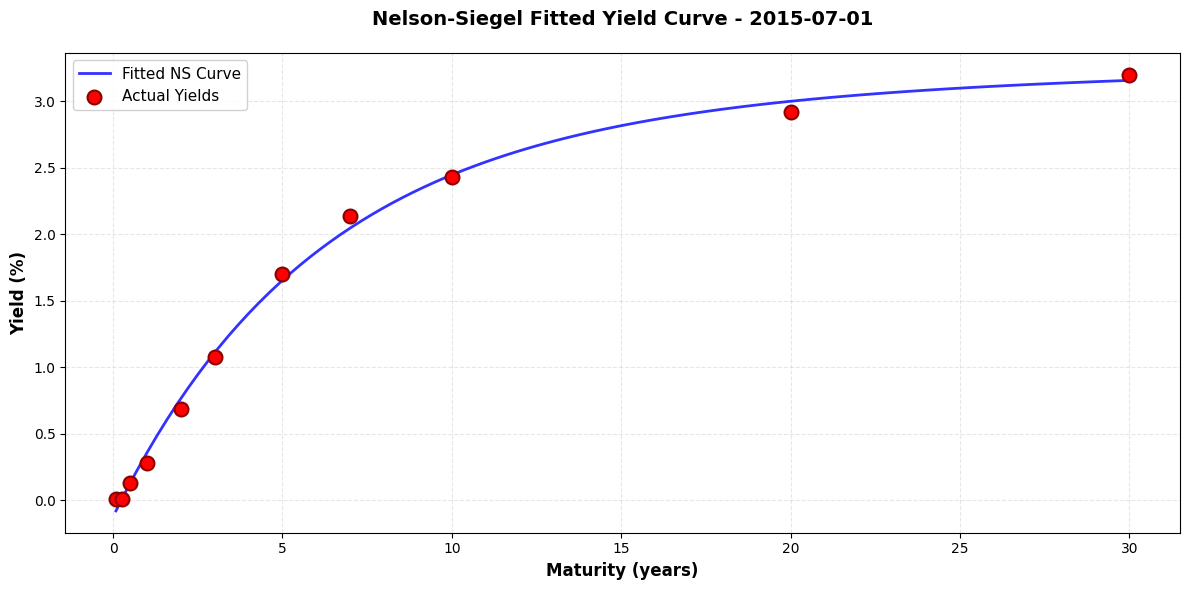

In [36]:
# Fit and plot the yield curve for a specific date
date_to_fit = '2015-07-01'

# Fit the Nelson-Siegel model
fitted_result = fit_ns_model(df, date_to_fit)

# Plot the results
plot_fitted_yield_curve(df, date_to_fit, fitted_result)

### Multiple Choice: FD-GCA-M1-Q6
Please use the Nelson Siegel model to answer this question on the left panel.

In [39]:
# Feel free to use this cell to find out answer for FD-GCA-M1-Q6

df.loc['2006-03-13', ['20_Year', '30_Year']]


20_Year    4.95
30_Year    4.77
Name: 2006-03-13 00:00:00, dtype: float64

## Part 5: Principal Component Analsys

In this section, you will perform Principal Component Analysis (PCA) to extract the key features that explain the variance in Treasury yields. Before conducting PCA, you need to standardize the dataset. A standardization function for the dataset  is provided to you below.

In [63]:
# Standardization function for a dataset
import numpy as np
import pandas as pd

def standardize_yields(yields):

    # Calculate means and standard deviations for each yield column
    yield_means = yields.mean()
    yield_stds = yields.std()
    
    # Apply standardization formula: Z = (X - μ) / σ
    standardize_yields = (yields - yield_means) / yield_stds
    
    return standardize_yields

Your task is to implement a function that computes how much variance each principal component explains.

**Function Requirements:**

- **Input:** 
  - `standardized_yields`: A pandas DataFrame containing standardized Treasury yield data (mean=0, std=1)

- **Output:** 
  - A pandas DataFrame with index from 1 to n_components containing:
    - Column `'Eigenvalue'`: eigenvalues sorted in descending order
    - Column `'Variance Explained (%)'`: percentage of total variance explained by each component


### Code Task: FD-GCA-M1-Q7

In [64]:
##############################################
# FD-GCA-M1-Q7
###############################################
# Principal Component Analysis

import numpy as np
import pandas as pd

def compute_pca_variance_explained(standardize_yields):

    ####################################
    # TODO: Complete your code here
    ####################################
    
    # Hint: Calculate the covariance matrix of standardized_yields
    cov_matrix = standardize_yields.cov()
    
    # Hint: Calculate eigenvalues and eigenvectors using np.linalg.eig()
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort eigenvalues in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues_sorted = eigenvalues[sorted_indices]
    
    # Hint: Calculate total variance using np.sum()
    total_variance = np.sum(eigenvalues_sorted)

    # Hint: Calculate variance explained percentage ((x/y)*100)
    variance_explained_pct = (eigenvalues_sorted / total_variance) * 100
    
    # Hint: Create DataFrame with proper index starting from 1
    n_components = len(eigenvalues_sorted)
    result_df = pd.DataFrame({
        'Eigenvalue': eigenvalues_sorted,
        'Variance Explained (%)': variance_explained_pct
    }, index=range(1, n_components + 1))
    
    return result_df

Now we can standardize our yield data and then conduct Principal Component Analysis.

In [65]:
standardized_data = standardize_yields(df)
pca_result = compute_pca_variance_explained(standardized_data)
pca_result

,Eigenvalue,Variance Explained (%)
1,9.222362,83.839658
2,1.633410,14.849184
3,0.117348,1.066797
4,0.014675,0.133407
5,0.005372,0.048834
6,0.003701,0.033650
7,0.001613,0.014664
8,0.000697,0.006341
9,0.000412,0.003746
10,0.000247,0.002247


### Multiple Choice: FD-GCA-M1-Q8
Use the above PCA result to answer this question on the left panel.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
